## Question

Frankenstein is told through Walton's letters containing Victor's
account, which contain the creature's. People argue whether Shelley gave each character their own distinct voice, making them feel like different characters.

## Data sources

Frankenstein_1831.txt from Project Gutenberg (1831 edition)

## Approach

1. It is important to segment the book by narrator in order to have a clear sample of each voicing  pattern.
2. Strip any punctuation or formatting differences that would clearly indicate one character vs another.
3. Compare between-narrator distance against within-narrator distance.
4. Visualize the data with some form of frequency matrix.

## Anticipated problems

1. Victor narrates far more than Walton, so Walton may not have enough data.
2. The boundaries between voices are not always clearly denoted. Victor resumes narration mid-scene, so chapter divisions may not correspond to changes in character.
3. The interpretation of positive vs negative results in the experiment could be difficult to interpret due to some decisions being Shelley's stylistic choices.

# Initial data processing

The data needs to be cleaned before processing. This involves clearing any gutenberg data and deciding the cutoff points between narrators.

After, they need to be tokenized and divided into 1000 word chunks for comparison.

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Dividing by narrator

In [2]:
file = open("frankenstein_1831.txt", "r", encoding="utf-8")
raw_text = file.read()
file.close()

#removes gutenberg licence
end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"
raw_text = raw_text.split(end_marker)[0]

#finds narrator boundaries
letter1 = raw_text.find("\nLetter 1\n")
chapter1 = raw_text.find("\nChapter 1\n")
chapter11 = raw_text.find("\nChapter 11\n")
chapter17 = raw_text.find("\nChapter 17\n")
continuation = raw_text.find("Walton, _in continuation._")

#assigns each section to each narrator
walton_text = raw_text[letter1:chapter1] + raw_text[continuation:]
victor_text = raw_text[chapter1:chapter11] + raw_text[chapter17:continuation]
creature_text = raw_text[chapter11:chapter17]

narrator_texts = {
    "Walton": walton_text,
    "Victor": victor_text,
    "Creature": creature_text
}

### Creating word chunks

In [3]:
#converts the characters into words that can be used for analysis
def tokenize(text):
    # Remove basic structural labels.
    text = re.sub(r"(?im)^\s*chapter\s+\d+\s*$", " ", text)
    text = re.sub(r"(?im)^\s*letter\s+\d+\s*$", " ", text)
    text = re.sub(r"(?im)^\s*_?to mrs\. saville, england\._?\s*$", " ", text)
    text = re.sub(r"(?im)^\s*walton,\s*_?in continuation\._?\s*$", " ", text)

    text = text.replace("_", " ")
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

narrator_words = {}

for item in narrator_texts.items():
    narrator = item[0]
    text = item[1]
    
    words = tokenize(text)
    narrator_words[narrator] = words
    
    print(narrator, len(words), "words")

Walton 10811 words
Victor 49318 words
Creature 15113 words


In [4]:
#creates chunks of 1000 words
def make_chunks(words):
    chunks = []

    for i in range(0, len(words) - 1000 + 1, 1000):
        chunks.append(words[i:i + 1000])

    return chunks

all_chunks = {}

#creates chunk for each narrator
for narrator in narrator_words:
    words = narrator_words[narrator]
    chunks = make_chunks(words)
    all_chunks[narrator] = chunks
    print(narrator, len(chunks), "full chunks")

#finds min chunk count across the narrators
chunk_lengths = []
for narrator in all_chunks:
    chunks = all_chunks[narrator]
    chunk_lengths.append(len(chunks))

n_chunks = min(chunk_lengths)

#creates the final chunks with equal number for each narrator
final_chunks = {}

for narrator in all_chunks:
    chunks = all_chunks[narrator]
    final_chunks[narrator] = chunks[:n_chunks]

print("\n", n_chunks, "chunks per narrator.")

Walton 10 full chunks
Victor 49 full chunks
Creature 15 full chunks

 10 chunks per narrator.


### Finding commonly used words in the samples

In [5]:
samples = []

#creates a list containing dictionaries for identifying each chunk
for narrator in ["Walton", "Victor", "Creature"]:
    i = 1
    for chunk in final_chunks[narrator]:
        samples.append({
            "sample": narrator[0] + str(i),
            "narrator": narrator,
            "words": chunk
        })
        i += 1

total_counts = Counter()

for sample in samples:
    total_counts.update(sample["words"])

#gets the list of 100 most common words in (word, count) format
common_word_tuples = total_counts.most_common(100)

#puts just the words into a list
vocabulary = []
for item in common_word_tuples:
    word = item[0]
    vocabulary.append(word)


print("20 most common words:")
print(vocabulary[:20])

20 most common words:
['the', 'and', 'of', 'i', 'to', 'my', 'a', 'in', 'was', 'that', 'his', 'he', 'with', 'but', 'had', 'which', 'me', 'it', 'as', 'by']


In [6]:
rows = []

#goes through each of the samples and counts the amount of times each word appears
for sample in samples:
    counts = Counter(sample["words"])
    row = {
        "sample": sample["sample"],
        "narrator": sample["narrator"]
    }

#after getting the word counts the frequency is calculated and appended to the list
    for word in vocabulary:
        row[word] = counts[word] / len(sample["words"])

    rows.append(row)

freq_df = pd.DataFrame(rows)

freq_df.head()

,sample,narrator,the,and,of,i,to,my,a,in,...,there,even,its,never,up,made,while,said,towards,after
0,W1,Walton,0.058,0.035,0.035,0.035,0.029,0.038,0.024,0.021,...,0.004,0.001,0.003,0.002,0.001,0.002,0.000,0.000,0.001,0.000
1,W2,Walton,0.041,0.035,0.037,0.041,0.032,0.022,0.027,0.020,...,0.003,0.002,0.001,0.004,0.000,0.001,0.000,0.000,0.001,0.000
2,W3,Walton,0.042,0.026,0.026,0.035,0.034,0.028,0.026,0.014,...,0.002,0.001,0.001,0.002,0.000,0.000,0.001,0.000,0.003,0.001
3,W4,Walton,0.060,0.027,0.029,0.021,0.030,0.005,0.027,0.019,...,0.002,0.001,0.000,0.003,0.005,0.000,0.000,0.003,0.003,0.004
4,W5,Walton,0.043,0.034,0.031,0.027,0.029,0.028,0.022,0.010,...,0.000,0.002,0.000,0.001,0.002,0.001,0.000,0.002,0.000,0.000


# Finding distance between narrators

This uses mean absolute distance to compare commonly used words across every chunk. This is then averaged to compare the true distance between different narrators.

In [7]:
def mean_absolute_distance(a, b):
    #find absolute difference
    differences = np.abs(a - b)
    #find average difference
    distance = np.mean(differences)
    return distance

#keeps the 100 frequency columns and converts them into a numpy array.
frequency_matrix = freq_df[vocabulary].to_numpy()
labels = freq_df["sample"].tolist()
narrators = freq_df["narrator"].tolist()


#empty distance matrix
distance_matrix = np.zeros((len(frequency_matrix), len(frequency_matrix)))

#compares the frequencies in each chunk to all the others
for i in range(len(frequency_matrix)):
    for j in range(len(frequency_matrix)):
        distance_matrix[i, j] = mean_absolute_distance(frequency_matrix[i], frequency_matrix[j])

comparisons = []

#checks if the comparisons are with other narrators or the same narrator
for i in range(len(frequency_matrix)):
    for j in range(i + 1, len(frequency_matrix)):
        if narrators[i] == narrators[j]:
            comparison_type = "Within narrator"
        else:
            comparison_type = "Between narrators"

        #adds the type into the comparisons list
        comparisons.append({
            "sample_1": labels[i],
            "sample_2": labels[j],
            "type": comparison_type,
            "distance": distance_matrix[i, j]
        })

#convert to df for calculation
comparison_df = pd.DataFrame(comparisons)
#finds average distance within narrators and between narrators so we can compare
comparison_df.groupby("type")["distance"].mean()

type
Between narrators    0.003386
Within narrator      0.002892
Name: distance, dtype: float64

# Visualizing the data

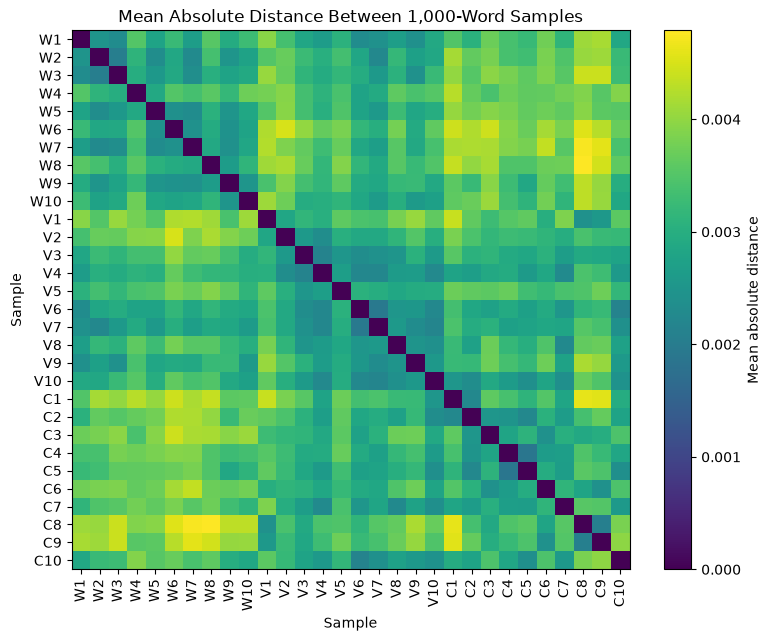

In [8]:
plt.figure(figsize=(9, 7))
plt.imshow(distance_matrix, aspect="auto")
plt.colorbar(label="Mean absolute distance")

plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)

plt.title("Mean Absolute Distance Between 1,000-Word Samples")
plt.xlabel("Sample")
plt.ylabel("Sample")
plt.show()

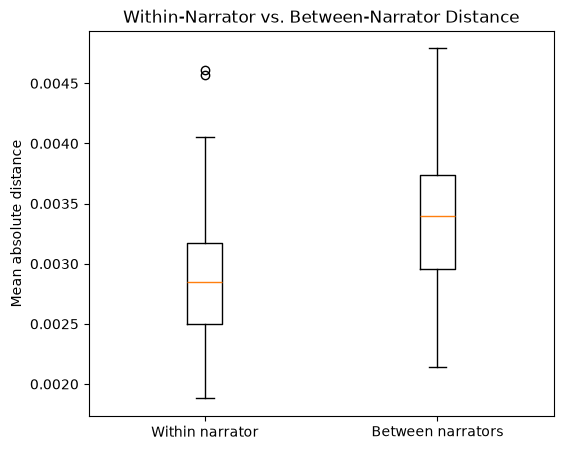

Mean within-narrator distance: 0.0029
Mean between-narrator distance: 0.0034
Difference: 0.0005


In [9]:
grouped = comparison_df.groupby("type")["distance"]
within = grouped.get_group("Within narrator")
between = grouped.get_group("Between narrators")

plt.figure(figsize=(6, 5))
plt.boxplot([within, between],tick_labels=["Within narrator", "Between narrators"])
plt.ylabel("Mean absolute distance")
plt.title("Within-Narrator vs. Between-Narrator Distance")
plt.show()

print("Mean within-narrator distance:", round(within.mean(), 4))
print("Mean between-narrator distance:", round(between.mean(), 4))
print("Difference:", round(between.mean() - within.mean(), 4))


# Conclusion

Overall, the within-narrator distances are less than the between narrator distances which shows that the narrators have measurably different word-frequency patterns. However, the difference is very small, which suggests very subtle stylistic choices rather than completely different voice profiles.

The distance matrix shows the similarity between word frequencies, showing how the voicing shows very subtle differences. However, the box plots show a clearer visualization of the overall difference across all the chunks.

